In [1]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1 -> 26.0.1
[notice] To update, run: C:\Users\arthu\AppData\Local\Programs\Python\Python312\python.exe -m pip install --upgrade pip


Carregando o dataset na memória...
=== Avaliando modelo para K = 1 ===

Relatório de Métricas:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        15
Iris-versicolor       0.94      0.94      0.94        17
 Iris-virginica       0.92      0.92      0.92        13

       accuracy                           0.96        45
      macro avg       0.95      0.95      0.95        45
   weighted avg       0.96      0.96      0.96        45



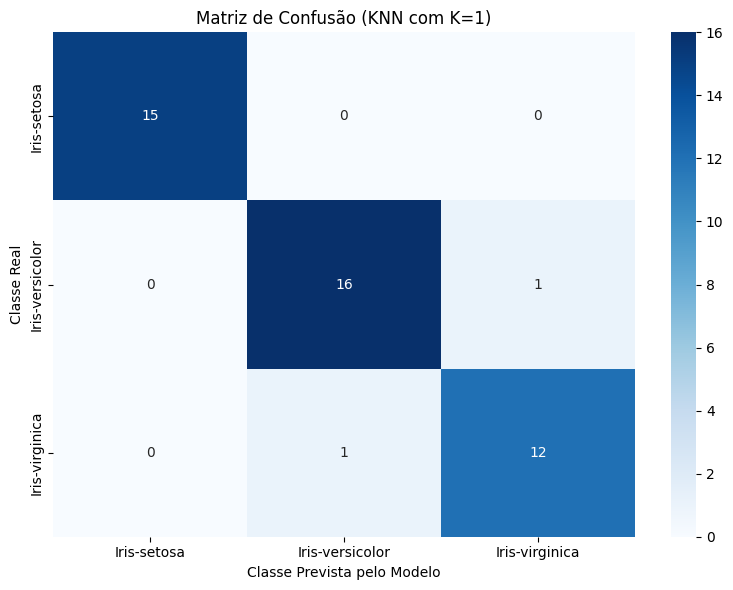

=== Avaliando modelo para K = 3 ===

Relatório de Métricas:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        15
Iris-versicolor       0.89      0.94      0.91        17
 Iris-virginica       0.92      0.85      0.88        13

       accuracy                           0.93        45
      macro avg       0.94      0.93      0.93        45
   weighted avg       0.93      0.93      0.93        45



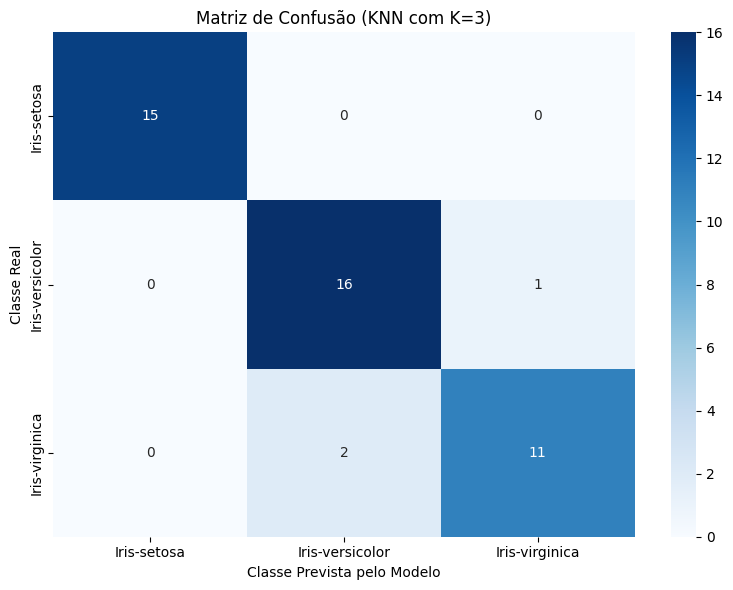

=== Avaliando modelo para K = 5 ===

Relatório de Métricas:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        15
Iris-versicolor       0.94      0.94      0.94        17
 Iris-virginica       0.92      0.92      0.92        13

       accuracy                           0.96        45
      macro avg       0.95      0.95      0.95        45
   weighted avg       0.96      0.96      0.96        45



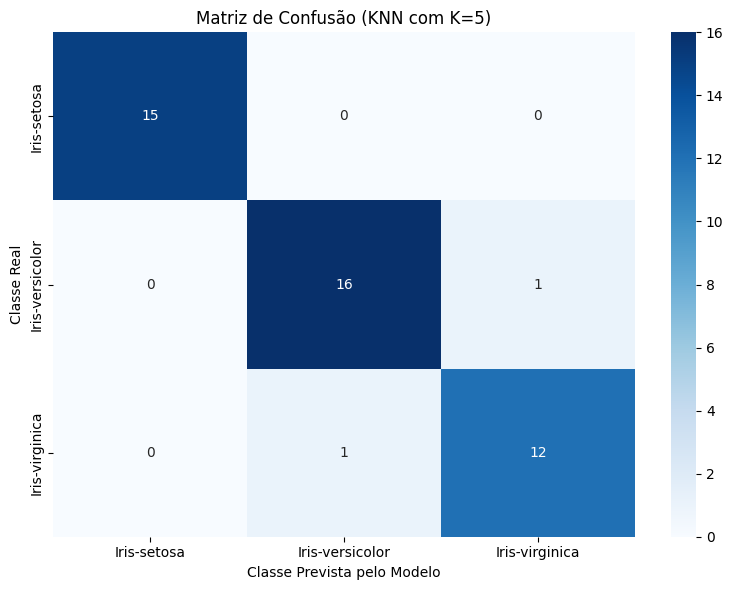

=== Avaliando modelo para K = 7 ===

Relatório de Métricas:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        15
Iris-versicolor       1.00      0.94      0.97        17
 Iris-virginica       0.93      1.00      0.96        13

       accuracy                           0.98        45
      macro avg       0.98      0.98      0.98        45
   weighted avg       0.98      0.98      0.98        45



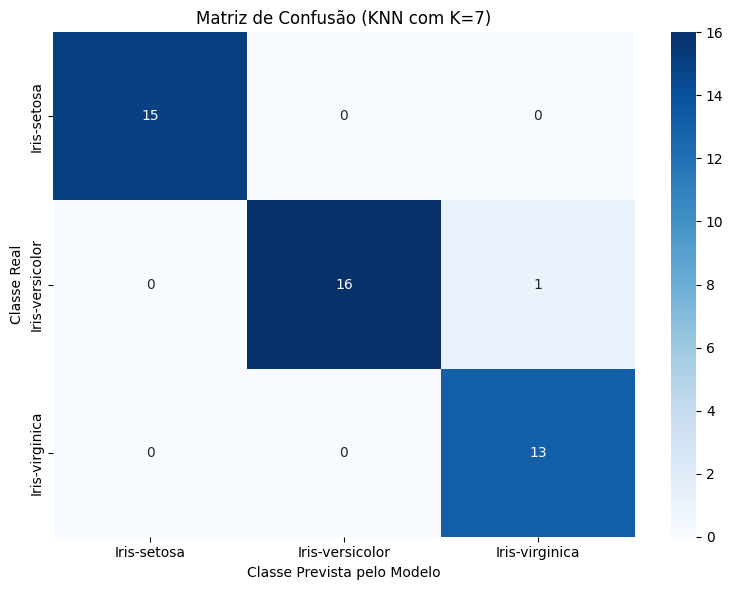

In [5]:
import math
import pandas as pd
from collections import Counter
import random
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

caminhoDados = r"M:\Programacao\Inteligencia Artificial\datasets\Iris.csv"

class Ponto:
    def __init__(self, id, sepalLengthCm, sepalWidthCm, petalLengthCm, petalWidthCm, species):
        self.id = id
        self.sepalLengthCm = sepalLengthCm
        self.sepalWidthCm = sepalWidthCm
        self.petalLengthCm = petalLengthCm
        self.petalWidthCm = petalWidthCm
        self.species = species

    def calculaDistancia(self, ponto2):
        return math.sqrt((self.sepalLengthCm - ponto2.sepalLengthCm)**2 + 
                         (self.sepalWidthCm - ponto2.sepalWidthCm)**2 + 
                         (self.petalLengthCm - ponto2.petalLengthCm)**2 + 
                         (self.petalWidthCm - ponto2.petalWidthCm)**2)

def carregaTodosDados(caminho):
    pontos = []
    df = pd.read_csv(caminho)
    for index, linha in df.iterrows():
        novoPonto = Ponto(linha["Id"], linha["SepalLengthCm"], linha["SepalWidthCm"], 
                          linha["PetalLengthCm"], linha["PetalWidthCm"], linha["Species"])
        pontos.append(novoPonto)
    return pontos

def embaralhaEDivide(pontos, proporcao_treino=0.7):
    pontos_embaralhados = pontos.copy()
    random.shuffle(pontos_embaralhados)
    
    limite = int(len(pontos_embaralhados) * proporcao_treino)
    dadosTreino = pontos_embaralhados[:limite]
    dadosTeste = pontos_embaralhados[limite:]
    
    return dadosTreino, dadosTeste

def desempateKnn(vizinhos):
    especies = [v.species for v in vizinhos]
    contagem = Counter(especies)
    return contagem.most_common(1)[0][0]

def knn(dadosTreino, dadosTeste, k):
    resposta = []
    for i in dadosTeste:
        distancias = []
        for j in dadosTreino:
            distancia = i.calculaDistancia(j)
            distancias.append((distancia, j))
            
        distancias.sort(key=lambda x: x[0])
        vizinhosProximos = [x[1] for x in distancias[:k]]
        resposta.append(desempateKnn(vizinhosProximos))
    return resposta
    
def calculaAcuracia(dadosTreino, dadosTeste, k):
    previsoes = knn(dadosTreino, dadosTeste, k)
    acertos = 0
    for i in range(len(dadosTeste)):
        if dadosTeste[i].species == previsoes[i]:
            acertos += 1
    return (acertos / len(dadosTeste)) * 100

def avaliaModelo(dadosTreino, dadosTeste, k):
    print(f"=== Avaliando modelo para K = {k} ===")

    previsoes = knn(dadosTreino, dadosTeste, k)
    reais = [ponto.species for ponto in dadosTeste]
    classes_iris = ['Iris-setosa', 'Iris-versicolor', 'Iris-virginica']
    
    relatorio = classification_report(reais, previsoes, target_names=classes_iris)
    print("\nRelatório de Métricas:")
    print(relatorio)
    
    matriz = confusion_matrix(reais, previsoes, labels=classes_iris)
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(matriz, annot=True, fmt='d', cmap='Blues', 
                xticklabels=classes_iris, yticklabels=classes_iris)
    
    plt.title(f'Matriz de Confusão (KNN com K={k})')
    plt.xlabel('Classe Prevista pelo Modelo')
    plt.ylabel('Classe Real')
    
    plt.tight_layout()
    plt.show()

print("Carregando o dataset na memória...")
todos_os_pontos = carregaTodosDados(caminhoDados)

dadosTreino, dadosTeste = embaralhaEDivide(todos_os_pontos, proporcao_treino=0.7)

ks = [1,3,5,7]
for i in ks: #Ao fechar uma matriz de confusão a do proximo k sera aberta automaticamente
  avaliaModelo(dadosTreino, dadosTeste, i)

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# Configurações de dados
caminhoDados = r"M:\Programacao\Inteligencia Artificial\datasets\Iris.csv"
colunas_caracteristicas = ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']
coluna_alvo = 'Species'

df = pd.read_csv(caminhoDados)
X = df[colunas_caracteristicas]
y = df[coluna_alvo]

# Divisão dos dados para o Sklearn
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

def avalia_sklearn(k):
    print(f"\n" + "="*30)
    print(f"MODELO SKLEARN: K = {k}")
    print("="*30)
    
    # Inicializa e treina o modelo
    knn_sk = KNeighborsClassifier(n_neighbors=k)
    knn_sk.fit(X_train, y_train)
    
    # Predição
    y_pred = knn_sk.predict(X_test)
    
    print("\nRelatório de Classificação:")
    print(classification_report(y_test, y_pred))
    
    acuracia = accuracy_score(y_test, y_pred)
    print(f"Acurácia Total: {acuracia * 100:.2f}%")
    
    plt.figure(figsize=(8, 6))
    matriz = confusion_matrix(y_test, y_pred)
    sns.heatmap(matriz, annot=True, fmt='d', cmap='Greens',
                xticklabels=df[coluna_alvo].unique(),
                yticklabels=df[coluna_alvo].unique())
    
    plt.title(f'Matriz de Confusão Sklearn (K={k})')
    plt.xlabel('Previsto')
    plt.ylabel('Real')
    plt.tight_layout()
    plt.show()

Iniciando teste manual...
=== Avaliando modelo para K = 1 ===

Relatório de Métricas:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        15
Iris-versicolor       0.94      0.94      0.94        17
 Iris-virginica       0.92      0.92      0.92        13

       accuracy                           0.96        45
      macro avg       0.95      0.95      0.95        45
   weighted avg       0.96      0.96      0.96        45



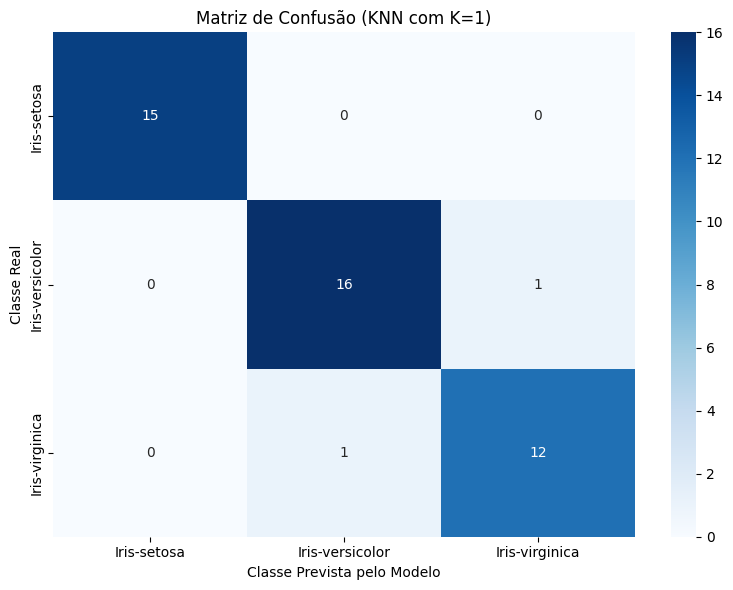

=== Avaliando modelo para K = 3 ===

Relatório de Métricas:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        15
Iris-versicolor       0.89      0.94      0.91        17
 Iris-virginica       0.92      0.85      0.88        13

       accuracy                           0.93        45
      macro avg       0.94      0.93      0.93        45
   weighted avg       0.93      0.93      0.93        45



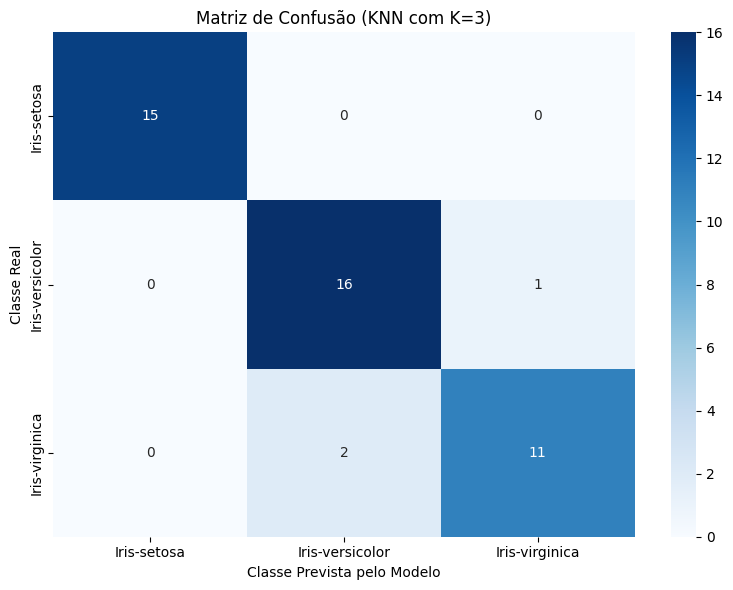

=== Avaliando modelo para K = 5 ===

Relatório de Métricas:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        15
Iris-versicolor       0.94      0.94      0.94        17
 Iris-virginica       0.92      0.92      0.92        13

       accuracy                           0.96        45
      macro avg       0.95      0.95      0.95        45
   weighted avg       0.96      0.96      0.96        45



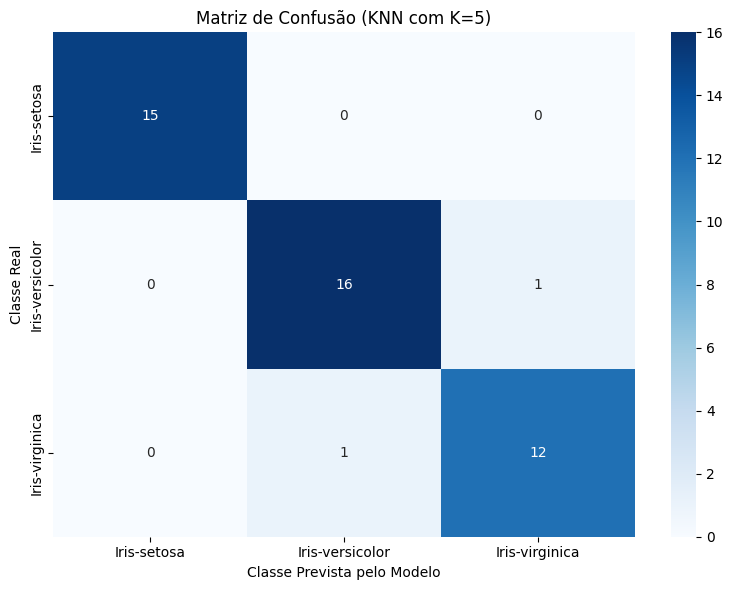

=== Avaliando modelo para K = 7 ===

Relatório de Métricas:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        15
Iris-versicolor       1.00      0.94      0.97        17
 Iris-virginica       0.93      1.00      0.96        13

       accuracy                           0.98        45
      macro avg       0.98      0.98      0.98        45
   weighted avg       0.98      0.98      0.98        45



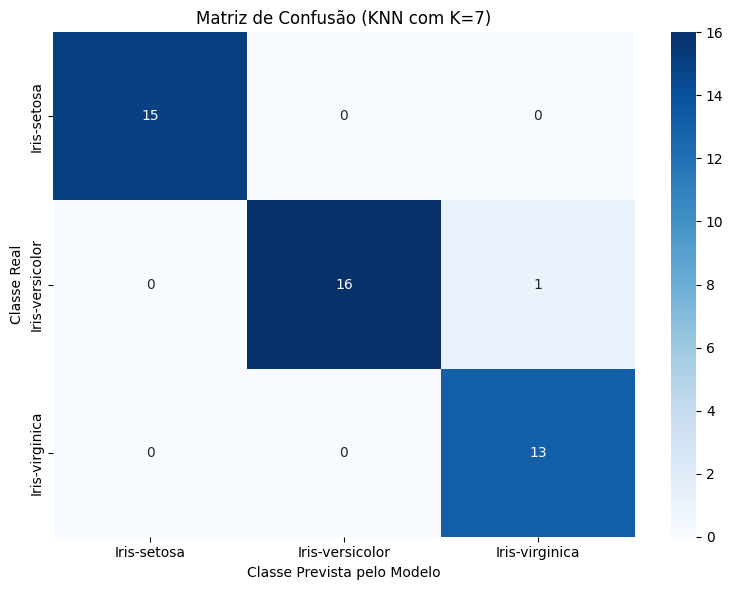

Tempo total da implementação manual: 1.45040 segundos

Iniciando teste Sklearn...

MODELO SKLEARN: K = 1

Relatório de Classificação:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        19
Iris-versicolor       1.00      1.00      1.00        13
 Iris-virginica       1.00      1.00      1.00        13

       accuracy                           1.00        45
      macro avg       1.00      1.00      1.00        45
   weighted avg       1.00      1.00      1.00        45

Acurácia Total: 100.00%


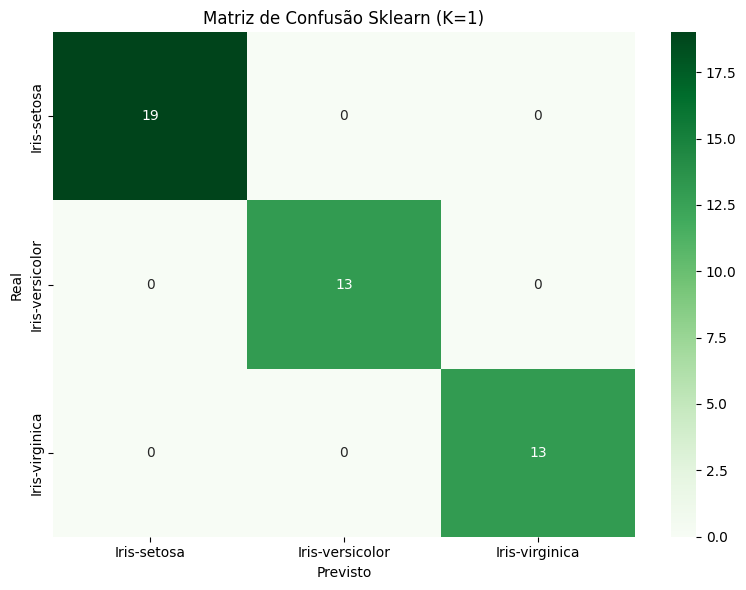


MODELO SKLEARN: K = 3

Relatório de Classificação:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        19
Iris-versicolor       1.00      1.00      1.00        13
 Iris-virginica       1.00      1.00      1.00        13

       accuracy                           1.00        45
      macro avg       1.00      1.00      1.00        45
   weighted avg       1.00      1.00      1.00        45

Acurácia Total: 100.00%


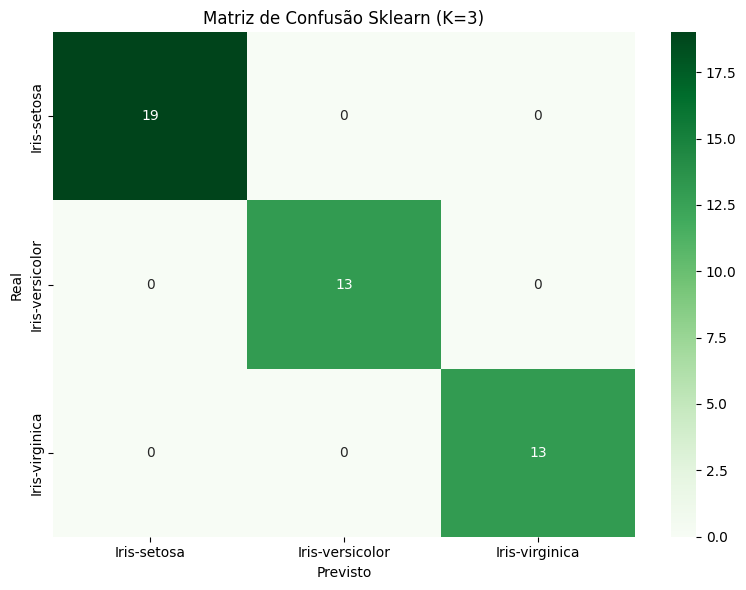


MODELO SKLEARN: K = 5

Relatório de Classificação:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        19
Iris-versicolor       1.00      1.00      1.00        13
 Iris-virginica       1.00      1.00      1.00        13

       accuracy                           1.00        45
      macro avg       1.00      1.00      1.00        45
   weighted avg       1.00      1.00      1.00        45

Acurácia Total: 100.00%


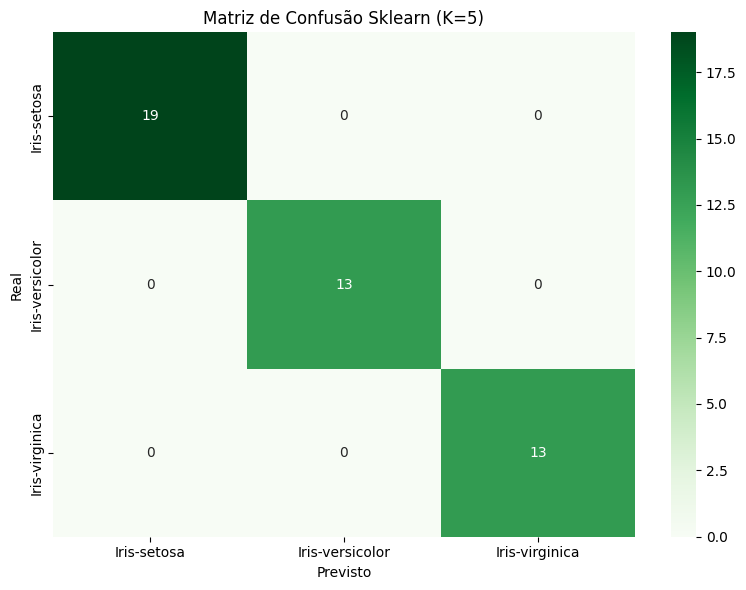


MODELO SKLEARN: K = 7

Relatório de Classificação:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        19
Iris-versicolor       1.00      1.00      1.00        13
 Iris-virginica       1.00      1.00      1.00        13

       accuracy                           1.00        45
      macro avg       1.00      1.00      1.00        45
   weighted avg       1.00      1.00      1.00        45

Acurácia Total: 100.00%


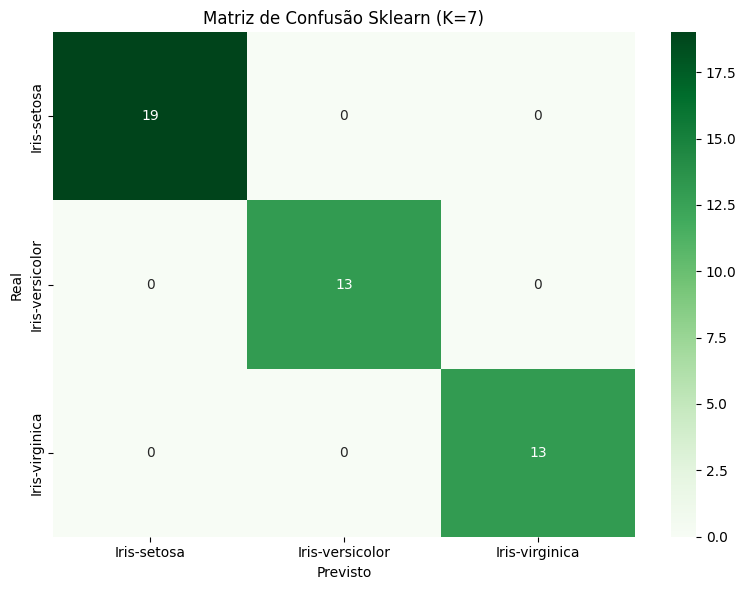

Tempo total da implementação Sklearn: 1.02206 segundos


In [10]:
import time

# --- PARTE 1: SEU CÓDIGO HARDCORE ---
print("Iniciando teste manual...")
start_time = time.time()

# Seu loop que já existe no código:
for i in [1, 3, 5, 7]:
    avaliaModelo(dadosTreino, dadosTeste, i)

end_time = time.time()
tempo_hardcore = end_time - start_time
print(f"Tempo total da implementação manual: {tempo_hardcore:.5f} segundos")

# --- PARTE 2: CÓDIGO SKLEARN ---
print("\nIniciando teste Sklearn...")
start_time_sk = time.time()

# O loop da implementação com biblioteca:
for i in [1, 3, 5, 7]:
    avalia_sklearn(i) # Nome da função que você criou para o Sklearn

end_time_sk = time.time()
tempo_sklearn = end_time_sk - start_time_sk
print(f"Tempo total da implementação Sklearn: {tempo_sklearn:.5f} segundos")